</p>
<h1><b><center></center></b></h1>
<h1><b><center>Mecánica Celeste 2026-1</center></b></h1>
<h3><b><center>Proyecto del Curso:</center></b><h3>
<h2><b><center>La aproximación de Apophis en 2029</center></b><h2>
<h3><b><center>Por Sofía Uribe Rodríguez</center></b></h3>
</p>

## El asteroide Apophis (99942) y su importancia como objeto de análisis y aplicación de conceptos de Mecánica Celeste

El asteroide Apophis (99942) fue descubierto en 2004 y desde entonces se ha rastreado y estudiado debido a que está clasificado como un Near-Earth Asteroid (asteroide cercano a la Tierra) y a su vez como un asteroide potencialmente peligroso, puesto que en abril de 2029 se aproximará a nuestro planeta a una distancia de aproximadamente 32 mil kilómetros, que es menor a la distancia a la que se encuentran algunos satélites en órbita geosincrónica.

Gracias a su paso cercano y a su tamaño de aproximadamente 375 metros, Apophis podrá ser visto a ojo desnudo en el cielo nocturno desde algunas regiones de nuestro planeta. Este evento es sumamente especial y representa una gran oportunidad y motivación para poner en práctica muchos de los conocimientos que un astrónomo va adquiriendo a lo largo de su formación académica.

En este caso, el objetivo es acercarnos a Apophis a través de una mirada enfocada en sus interacciones gravitacionales mayormente clásicas y describirlo por medio de algunos de los conceptos y herramientas computacionales aprendidos en el curso de Mecánica Celeste.

## Definiendo en enfoque
El objetivo es utilizar (casi) todas las herramientas computacionales que se han desarrollado a lo largo del semestre en el curso de Mecánica Celeste, clasificando los análisis en 3 grandes marcos: Problema de N cuerpos, problema de 2 cuerpos y problema de 3 cuerpos.

Tanto en la primera parte como en la tercera, se va a considerar únicamente al sistema conformado por el Sol, la Tierra y el asteroide Apophis, excluyendo demás cuerpos, grandes o pequeños, del Sistema Solar.

Por el contrario, y como puede ser obvio, en la segunda parte sólo se van a considerar sistemas de 2 cuerpos, ya sea Sol-Apophis o Tierra-Apophis.

In [ ]:
# Herramientas necesarias
!pip install -Uq pymcel celluloid rebound plotly nbformat

import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt
from celluloid import Camera
import rebound
from datetime import datetime, timedelta
from astropy.time import Time
from scipy.optimize import newton
import spiceypy as spy
from IPython.display import HTML
from scipy.integrate import solve_ivp
import plotly.graph_objects as go
from spiceypy.utils.support_types import c_matrix_to_numpy
from mpl_toolkits.mplot3d import Axes3D

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 908.6/908.6 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 70.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 41.7 MB/s eta 0:00:00
Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


## **Primera Parte: El Problema de los N-Cuerpos**


**Calculando la Fuerza Gravitacional:**

Comparación entre las magnitudes de la fuerza que ejercen tanto el Sol como la Tierra sobre el asteroide Apophis.

In [ ]:
# @title
import warnings
from erfa import ErfaWarning
warnings.filterwarnings('ignore', category=ErfaWarning)

In [ ]:
# Elementos del sistema y sus masas
m_tierra = pc.constantes.M_earth
m_sol = pc.constantes.M_sun
m_apophis = 2.3e10  # En kg, masa aproximada

# Distancia de la Tierra al baricentro
tabla, jd, X = pc.consulta_horizons(id='399', location='@SSB', epochs='2029-04-13')
r_tierra = X[0:3]

# Distancia de Apophis al baricentro
tabla, jd, X = pc.consulta_horizons(id='99942', location='@SSB', epochs='2029-04-13')
r_apophis = X[0:3]

#Posición del Sol
tabla, jd, X = pc.consulta_horizons(id='0', location='@SSB', epochs='2029-04-13')
r_sol = X[0:3]

# Distancia entre elementos
r_tierra_sol = r_tierra - r_sol
r_apophis_sol = r_apophis - r_sol
r_tierra_apophis = r_tierra - r_apophis

# Fuerzas
F_apophis_sol = pc.constantes.G * m_apophis * m_sol * r_apophis_sol / np.linalg.norm(r_apophis_sol)**3
F_apophis_sol
F_tierra_apophis = pc.constantes.G * m_tierra * m_apophis * r_tierra_apophis / np.linalg.norm(r_tierra_apophis)**3
F_tierra_apophis

# Comparación
magnitud_F_tierra_apophis = np.linalg.norm(F_tierra_apophis)
magnitud_F_sol_apophis = np.linalg.norm(F_apophis_sol)

print(f"Magnitud de la fuerza del Sol sobre Apophis: {magnitud_F_sol_apophis:.3e} N.")
print(f"Magnitud de la fuerza de la Tierra sobre Apophis: {magnitud_F_tierra_apophis:.3e} N.")

if magnitud_F_sol_apophis > magnitud_F_tierra_apophis:
    print(f"La fuerza del Sol sobre Apophis es {magnitud_F_sol_apophis / magnitud_F_tierra_apophis:.2f} veces mayor que la fuerza de la Tierra sobre el asteroide.")
elif magnitud_F_tierra_apophis > magnitud_F_sol_apophis:
    print(f"La fuerza de la Tierra sobre Apophis es {magnitud_F_tierra_apophis / magnitud_F_sol_apophis:.2f} veces mayor que la fuerza del Sol sobre el asteroide.")
else:
    print("Ambas fuerzas tienen magnitudes similares.")

Magnitud de la fuerza del Sol sobre Apophis: 1.350e+08 N.
Magnitud de la fuerza de la Tierra sobre Apophis: 3.920e+07 N.
La fuerza del Sol sobre Apophis es 3.45 veces mayor que la fuerza de la Tierra sobre el asteroide.


*Una diferencia en fuerza de 3.45 veces en realidad no es tanto, si se consideran sólo las masas del Sol, la Tierra y Apophis. Sin embargo, es necesario tener en cuenta que para el análisis anterior se utilizó la fecha de máxima aproximación entre nuestro planeta y el asteroide prevista por NASA.*

**Método de Euler para N-Cuerpos:**

Cálculo de las órbitas de los 3 cuerpos a partir de obtener sus posiciones y velocidades por el método de Euler.

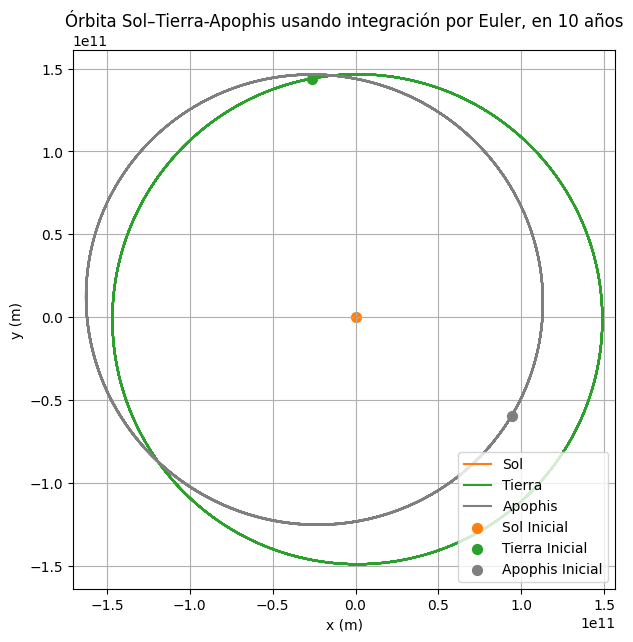

In [ ]:
# Posiciones y velocidades iniciales de nuestros 3 elementos
tabla, jd, X_sol = pc.consulta_horizons(id='0', location='@SSB', epochs='2026-01-01 00:00:00')
r_sol_0 = X_sol[:3]
v_sol_0 = X_sol[3:]

tabla, jd, X_tierra = pc.consulta_horizons(id='399', location='@SSB', epochs='2026-01-01 00:00:00')
r_tierra_0 = X_tierra[:3]
v_tierra_0 = X_tierra[3:]

tabla, jd, X_apophis = pc.consulta_horizons(id='99942', location='@SSB', epochs='2026-01-01 00:00:00')
r_apophis_0 = X_apophis[:3]
v_apophis_0 = X_apophis[3:]

# Constantes físicas
G = pc.constantes.G
deltat = 1 * 86400  # un día en segundos

# Masas
m_tierra = pc.constantes.M_earth
m_sol = pc.constantes.M_sun
m_apophis = 2.3e10  # En kg, masa aproximada, como se definió previamente

# Parámetros gravitacionales
mu_sol = pc.constantes.mu_sun
mu_tierra = pc.constantes.mu_earth
mu_apophis = G * m_apophis

years = 10
seconds_per_year = 365.25 * 86400
T_total = years * seconds_per_year
N_steps = int(T_total // deltat)

# Inicializamos posiciones y velocidades con los valores actuales
r_sol = r_sol_0.copy()
v_sol = v_sol_0.copy()
r_tierra = r_tierra_0.copy()
v_tierra = v_tierra_0.copy()
r_apophis = r_apophis_0.copy()
v_apophis = v_apophis_0.copy()

# Listas para guardar la trayectoria
r_sol_hist = []
r_tierra_hist = []
r_apophis_hist = []

for _ in range(N_steps):
    # Guardamos posiciones actuales
    r_sol_hist.append(r_sol.copy())
    r_tierra_hist.append(r_tierra.copy())
    r_apophis_hist.append(r_apophis.copy())

    # Vectores de separación y sus magnitudes
    r_sol_tierra_vec = r_tierra - r_sol
    norm_sol_tierra = np.linalg.norm(r_sol_tierra_vec)
    r_sol_apophis_vec = r_apophis - r_sol
    norm_sol_apophis = np.linalg.norm(r_sol_apophis_vec)

    r_tierra_sol_vec = r_sol - r_tierra
    norm_tierra_sol = np.linalg.norm(r_tierra_sol_vec)
    r_tierra_apophis_vec = r_apophis - r_tierra
    norm_tierra_apophis = np.linalg.norm(r_tierra_apophis_vec)

    r_apophis_sol_vec = r_sol - r_apophis
    norm_apophis_sol = np.linalg.norm(r_apophis_sol_vec)
    r_apophis_tierra_vec = r_tierra - r_apophis
    norm_apophis_tierra = np.linalg.norm(r_apophis_tierra_vec)

    # Calculamos las aceleraciones para cada cuerpo (suma de las aceleraciones debidas a los otros dos)
    # Aceleración del Sol debido a la Tierra y Apophis
    a_sol = (mu_tierra * r_sol_tierra_vec / norm_sol_tierra**3) + \
            (mu_apophis * r_sol_apophis_vec / norm_sol_apophis**3)

    # Aceleración de la Tierra debido al Sol y Apophis
    a_tierra = (mu_sol * r_tierra_sol_vec / norm_tierra_sol**3) + \
               (mu_apophis * r_tierra_apophis_vec / norm_tierra_apophis**3)

    # Aceleración de Apophis debido al Sol y la Tierra
    a_apophis = (mu_sol * r_apophis_sol_vec / norm_apophis_sol**3) + \
                (mu_tierra * r_apophis_tierra_vec / norm_apophis_tierra**3)

    # Integración tipo Euler
    v_sol = v_sol + a_sol * deltat
    r_sol = r_sol + v_sol * deltat

    v_tierra = v_tierra + a_tierra * deltat
    r_tierra = r_tierra + v_tierra * deltat

    v_apophis = v_apophis + a_apophis * deltat
    r_apophis = r_apophis + v_apophis * deltat

# Convertir las listas de historial a arrays de Numpy
r_sol_hist = np.array(r_sol_hist)
r_tierra_hist = np.array(r_tierra_hist)
r_apophis_hist = np.array(r_apophis_hist)

# Gráfica de órbita en el plano XY
plt.figure(figsize=(7, 7))
plt.plot(r_sol_hist[:, 0], r_sol_hist[:, 1], label="Sol", color="tab:orange")
plt.plot(r_tierra_hist[:, 0], r_tierra_hist[:, 1], label="Tierra", color="tab:green")
plt.plot(r_apophis_hist[:, 0], r_apophis_hist[:, 1], label="Apophis", color="tab:gray")

# Posiciones iniciales
plt.scatter(r_sol_0[0], r_sol_0[1], color="tab:orange", s=50, marker="o", label="Sol Inicial")
plt.scatter(r_tierra_0[0], r_tierra_0[1], color="tab:green", s=50, marker="o", label="Tierra Inicial")
plt.scatter(r_apophis_0[0], r_apophis_0[1], color="tab:gray", s=50, marker="o", label="Apophis Inicial")

# Formato de la gráfica
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title(f"Órbita Sol–Tierra-Apophis usando integración por Euler, en {years} años")
plt.legend()
plt.axis("equal")
plt.grid()
plt.show()

¿Cuáles son los puntos de máximo acercamiento?

Distancia mínima entre la Tierra y Apophis: 1.302e+10 metros
Coordenadas de la Tierra en el punto más cercano: [-2.96624193e+10  1.43314716e+11  1.08206231e+07]
Coordenadas de Apophis en el punto más cercano: [-3.90301382e+10  1.45793210e+11 -8.68645908e+09]


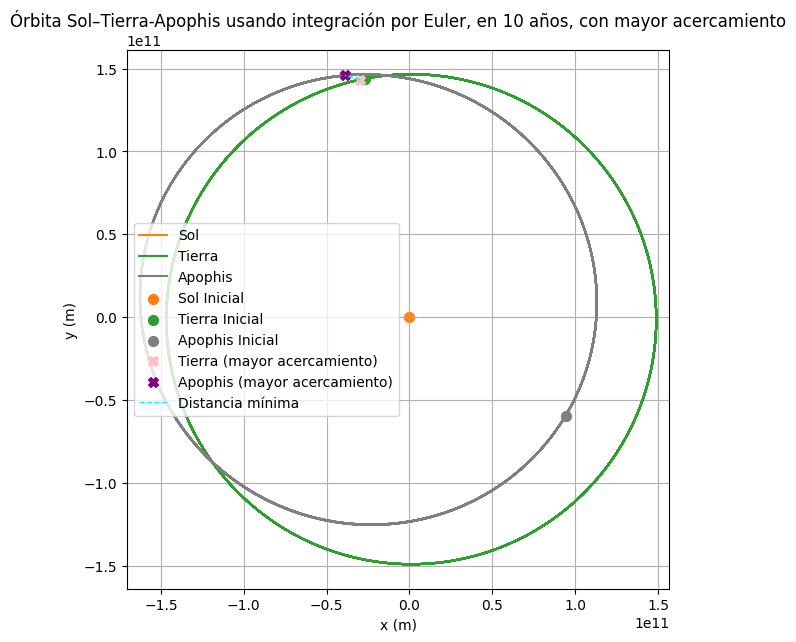

In [ ]:
# Calcular las distancias entre la Tierra y Apophis
distances = np.linalg.norm(r_tierra_hist - r_apophis_hist, axis=1)

# Encontrar el índice del mínimo acercamiento
min_distance_idx = np.argmin(distances)
min_distance = distances[min_distance_idx]

# Obtener las coordenadas de la Tierra y Apophis en el punto de mayor acercamiento
closest_tierra_coords = r_tierra_hist[min_distance_idx]
closest_apophis_coords = r_apophis_hist[min_distance_idx]

print(f"Distancia mínima entre la Tierra y Apophis: {min_distance:.3e} metros")
print(f"Coordenadas de la Tierra en el punto más cercano: {closest_tierra_coords}")
print(f"Coordenadas de Apophis en el punto más cercano: {closest_apophis_coords}")

# Re-graficar la órbita en el plano XY añadiendo el punto de mayor acercamiento
plt.figure(figsize=(7, 7))
plt.plot(r_sol_hist[:, 0], r_sol_hist[:, 1], label="Sol", color="tab:orange")
plt.plot(r_tierra_hist[:, 0], r_tierra_hist[:, 1], label="Tierra", color="tab:green")
plt.plot(r_apophis_hist[:, 0], r_apophis_hist[:, 1], label="Apophis", color="tab:gray")

# Posiciones iniciales
plt.scatter(r_sol_0[0], r_sol_0[1], color="tab:orange", s=50, marker="o", label="Sol Inicial")
plt.scatter(r_tierra_0[0], r_tierra_0[1], color="tab:green", s=50, marker="o", label="Tierra Inicial")
plt.scatter(r_apophis_0[0], r_apophis_0[1], color="tab:gray", s=50, marker="o", label="Apophis Inicial")

# Marcamos el punto de mayor acercamiento
plt.scatter(closest_tierra_coords[0], closest_tierra_coords[1], color="pink", s=50, marker="X", label="Tierra (mayor acercamiento)", zorder=2)
plt.scatter(closest_apophis_coords[0], closest_apophis_coords[1], color="purple", s=50, marker="X", label="Apophis (mayor acercamiento)", zorder=2)

# Conectamos los puntos de mayor acercamiento con una línea para visualizarlos
plt.plot([closest_tierra_coords[0], closest_apophis_coords[0]], [closest_tierra_coords[1], closest_apophis_coords[1]], '--', color='cyan', linewidth=1, label="Distancia mínima")

# Formato de la gráfica
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title(f"Órbita Sol–Tierra-Apophis usando integración por Euler, en {years} años, con mayor acercamiento")
plt.legend()
plt.axis("equal")
plt.grid()
plt.show()

¿En qué fecha ocurrirá este acercamiento?

In [ ]:
# Fecha de inicio de la simulación
start_date_str = '2026-01-01 00:00:00'
start_date = datetime.strptime(start_date_str, '%Y-%m-%d %H:%M:%S')

# Calcular el tiempo transcurrido hasta el punto de mínima distancia
elapsed_seconds = int(min_distance_idx * deltat)
elapsed_time = timedelta(seconds=elapsed_seconds)

# Calcular la fecha del mayor acercamiento
closest_approach_date = start_date + elapsed_time

print(f"La fecha aproximada del mayor acercamiento entre la Tierra y Apophis es: {closest_approach_date}")

La fecha aproximada del mayor acercamiento entre la Tierra y Apophis es: 2028-12-14 00:00:00


*La fecha real de la aproximación corresponde al 13 de abril de 2029. Es decir, hay una discrepancia de aproximadamente 4 meses. Sin embargo, debido a que no se están teniendo en cuenta las interacciones con todos los demás cuerpos del Sistema Solar, entre otros factores físicos, 4 meses es un error "tolerable".*

**Cuadraturas para N cuerpos:**

Primero añadamos una simulación de las trayectorias de los 3 cuerpos usando Rebound, además de visualizar la conservación de la energía total del sistema a los largo de 10 años.

También se encuentran cantidades conservadas, como el Momentum Lineal Total, el Momentum Angular Total y la Energía Total (mecánica + potencial).



/usr/local/lib/python3.12/dist-packages/pymcel/__init__.py:1413: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  solucion=odeint(edm_ncuerpos_eficiente,Y0s,ts,args=(N,mus))
/usr/local/lib/python3.12/dist-packages/pymcel/__init__.py:1446: RuntimeWarning: divide by zero encountered in divide
  U+=-0.5*mus[i]*mus[j]/rij


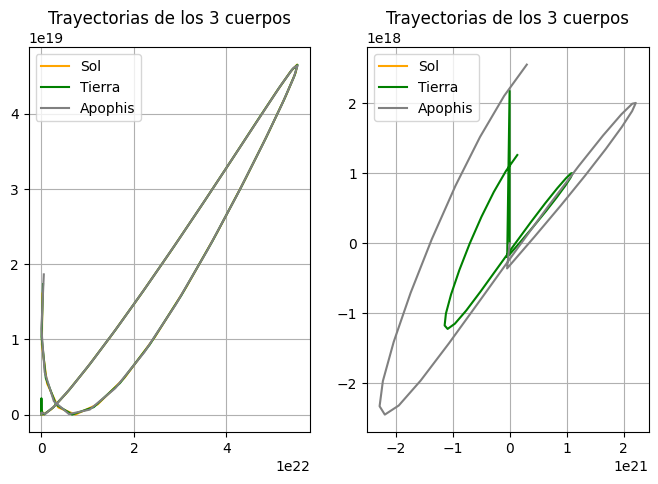

In [ ]:
# @title
# Nuestro sistema de 3 cuerpos
sistema = [
    dict(m = m_sol, r = [0, 0, 0], v = [0, 0, 0]),
    dict(m = m_tierra, r = [1, 0, 0], v = [0, 1, 0]),
    dict(m = m_apophis, r = [0, 1.37, 0], v = [0, 0, -1])
]

# Intervalo de tiempo para la integración
ts = np.linspace(0, 10, 200)

# Solución por pymcel
rs, vs, rps, vps, constantes = pc.ncuerpos_solucion(sistema, ts)

# Graficación
fig, axs = plt.subplots(1, 2, figsize=(8, 5))

ax = axs[0]
ax.plot(rs[0, :, 0], rs[0, :, 1], label='Sol', color='orange')
ax.plot(rs[1, :, 0], rs[1, :, 1], label='Tierra', color='green')
ax.plot(rs[2, :, 0], rs[2, :, 1], label='Apophis', color='gray')
ax.set_title('Trayectorias de los 3 cuerpos')
ax.legend()
ax.grid()

ax = axs[1]
ax.plot(rps[0, :, 0], rps[0, :, 1], label='Sol', color='orange')
ax.plot(rps[1, :, 0], rps[1, :, 1], label='Tierra', color='green')
ax.plot(rps[2, :, 0], rps[2, :, 1], label='Apophis', color='gray')
ax.set_title('Trayectorias de los 3 cuerpos')
ax.legend()
ax.grid()

plt.show()

# ????

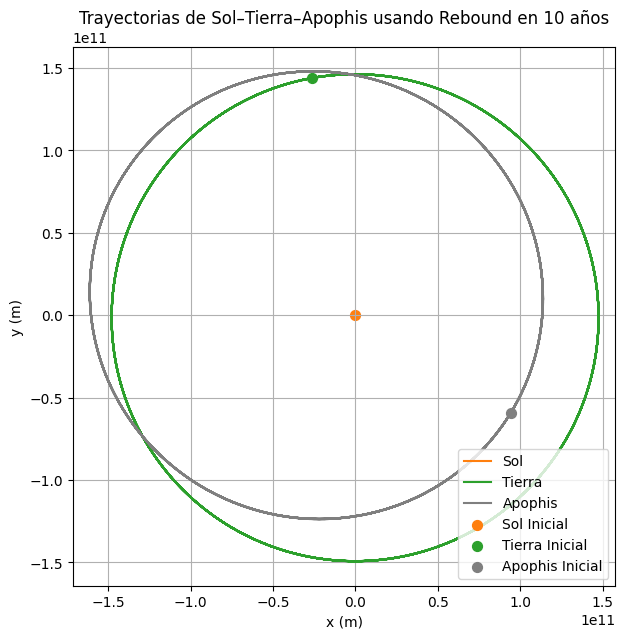

In [ ]:
# Simulación por Rebound
sim = rebound.Simulation()

sim.G = pc.constantes.G

# Sol
sim.add(m=m_sol, x=r_sol_0[0], y=r_sol_0[1], z=r_sol_0[2],
        vx=v_sol_0[0], vy=v_sol_0[1], vz=v_sol_0[2])

# Tierra
sim.add(m=m_tierra, x=r_tierra_0[0], y=r_tierra_0[1], z=r_tierra_0[2],
        vx=v_tierra_0[0], vy=v_tierra_0[1], vz=v_tierra_0[2])

# Apophis
sim.add(m=m_apophis, x=r_apophis_0[0], y=r_apophis_0[1], z=r_apophis_0[2],
        vx=v_apophis_0[0], vy=v_apophis_0[1], vz=v_apophis_0[2])

# IAS15 (alta precisión)
sim.integrator = "ias15"

# Duración
years = 10
T_total = years * 365.25 * 86400  # seconds

# Cantidad de puntos
N_outputs = 1000
times = np.linspace(0, T_total, N_outputs)

# Para guardar posiciones y velocidades
rebound_rs = np.zeros((sim.N, N_outputs, 3))
rebound_vs = np.zeros((sim.N, N_outputs, 3))

# Integrar y guardar nuevas posiciones y velocidades
for i, t in enumerate(times):
    sim.integrate(t)
    for j in range(sim.N):
        rebound_rs[j, i, :] = [sim.particles[j].x, sim.particles[j].y, sim.particles[j].z]
        rebound_vs[j, i, :] = [sim.particles[j].vx, sim.particles[j].vy, sim.particles[j].vz]

# Graficación
plt.figure(figsize=(7, 7))
plt.plot(rebound_rs[0, :, 0], rebound_rs[0, :, 1], label='Sol', color='tab:orange')
plt.plot(rebound_rs[1, :, 0], rebound_rs[1, :, 1], label='Tierra', color='tab:green')
plt.plot(rebound_rs[2, :, 0], rebound_rs[2, :, 1], label='Apophis', color='tab:gray')

# Posiciones iniciales
plt.scatter(rebound_rs[0, 0, 0], rebound_rs[0, 0, 1], color="tab:orange", s=50, marker="o", label="Sol Inicial")
plt.scatter(rebound_rs[1, 0, 0], rebound_rs[1, 0, 1], color="tab:green", s=50, marker="o", label="Tierra Inicial")
plt.scatter(rebound_rs[2, 0, 0], rebound_rs[2, 0, 1], color="tab:gray", s=50, marker="o", label="Apophis Inicial")

plt.title(f'Trayectorias de Sol–Tierra–Apophis usando Rebound en {years} años')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.legend()
plt.grid()
plt.axis('equal')
plt.show()

Las cantidades obtenidas por cuadraturas:

In [ ]:
def calculate_conservation_quantities(simulation):
    MLT = np.array([0.0, 0.0, 0.0])  # Momentum lineal total
    MAT = np.array([0.0, 0.0, 0.0])  # Momentum angular total
    K = 0.0  # Energía mecánica
    U = 0.0  # Energía potencial
    I = 0.0  # Momento de Inercia (respecto al origen)

    # MLT, MAT, K, I
    for p in simulation.particles:
        pos = np.array([p.x, p.y, p.z])
        vel = np.array([p.vx, p.vy, p.vz])
        MLT += p.m * vel
        MAT += p.m * np.cross(pos, vel)
        K += 0.5 * p.m * np.sum(vel**2)
        I += p.m * np.sum(pos**2)

    # U (en los 3 pares)
    for i in range(simulation.N):
        for j in range(i + 1, simulation.N):
            p1 = simulation.particles[i]
            p2 = simulation.particles[j]
            r_vec = np.array([p1.x - p2.x, p1.y - p2.y, p1.z - p2.z])
            dist = np.linalg.norm(r_vec)
            if dist > 0:  # Evita /0 (cuando están en el mismo punto)
                U -= simulation.G * p1.m * p2.m / dist

    E = K + U
    return MLT, MAT, K, U, E, I

# Crear una nueva simulación
initial_sim = rebound.Simulation()
initial_sim.G = pc.constantes.G
initial_sim.add(m=m_sol, x=r_sol_0[0], y=r_sol_0[1], z=r_sol_0[2], vx=v_sol_0[0], vy=v_sol_0[1], vz=v_sol_0[2])
initial_sim.add(m=m_tierra, x=r_tierra_0[0], y=r_tierra_0[1], z=r_tierra_0[2], vx=v_tierra_0[0], vy=v_tierra_0[1], vz=v_tierra_0[2])
initial_sim.add(m=m_apophis, x=r_apophis_0[0], y=r_apophis_0[1], z=r_apophis_0[2], vx=v_apophis_0[0], vy=v_apophis_0[1], vz=v_apophis_0[2])

# Estado inicial nuevo
MLT_initial, MAT_initial, K_initial, U_initial, E_initial, I_initial = calculate_conservation_quantities(initial_sim)
print("\nEstado Inicial del Sistema (t=0):")
print(f"Momentum Lineal Total: {MLT_initial}.")
print(f"Momentum Angular Total: {MAT_initial}.")
print(f"Energía Mecánica: {K_initial}.")
print(f"Energía Potencial: {U_initial}.")
print(f"Energía Total: {E_initial}.")
print(f"Momento de Inercia: {I_initial}.")

# Estado final (10 años)
MLT_final, MAT_final, K_final, U_final, E_final, I_final = calculate_conservation_quantities(sim)
print("\nEstado Final (t=10 años) del Sistema:")
print(f"Momentum Lineal Total: {MLT_final}.")
print(f"Momentum Angular Total: {MAT_final}.")
print(f"Energía Mecánica: {K_final}.")
print(f"Energía Potencial: {U_final}.")
print(f"Energía Total: {E_final}.")
print(f"Momento de Inercia: {I_final}.")


Estado Inicial del Sistema (t=0):
Momentum Lineal Total: [-1.77830293e+29 -3.22255948e+28  1.04742042e+24].
Momentum Angular Total: [ 4.99028903e+35 -1.89398963e+36  2.64530967e+40].
Energía Mecánica: 2.7345264559647866e+33.
Energía Potencial: -5.41486006572647e+33.
Energía Total: -2.680333609761683e+33.
Momento de Inercia: 1.2795133220371627e+47.

Estado Final (t=10 años) del Sistema:
Momentum Lineal Total: [-1.77830293e+29 -3.22255948e+28  1.04742042e+24].
Momentum Angular Total: [ 4.99028903e+35 -1.89398963e+36  2.64530967e+40].
Energía Mecánica: 2.689100990098532e+33.
Energía Potencial: -5.369434599860215e+33.
Energía Total: -2.6803336097616827e+33.
Momento de Inercia: 1.3176142764353784e+47.


Evolución de la energía total:

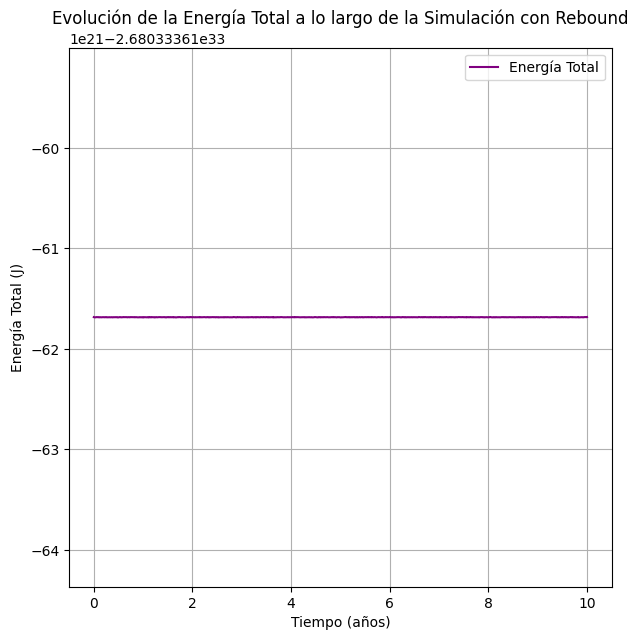

In [ ]:
total_energies = []

# Crea simulación dummy
dummy_sim = rebound.Simulation()
dummy_sim.G = pc.constantes.G

# Los cuerpos y sus masas
dummy_sim.add(m=m_sol)
dummy_sim.add(m=m_tierra)
dummy_sim.add(m=m_apophis)


for i in range(N_outputs):
    # Nuevas posiciones y velocidades
    for j in range(dummy_sim.N):
        p = dummy_sim.particles[j]
        p.x, p.y, p.z = rebound_rs[j, i, :]
        p.vx, p.vy, p.vz = rebound_vs[j, i, :]

    # Se extrae sólo la energía de cada paso
    _, _, _, _, E_current, _ = calculate_conservation_quantities(dummy_sim)
    total_energies.append(E_current)

# Graficar
plt.figure(figsize=(7, 7))
plt.plot(times / (365.25 * 86400), total_energies, label='Energía Total', color='purple') # Convertir t a años
plt.xlabel('Tiempo (años)')
plt.ylabel('Energía Total (J)')
plt.title('Evolución de la Energía Total a lo largo de la Simulación con Rebound')
plt.grid()
plt.legend()

*Que la energía total corresponda a un valor negativo implica que el sistema está ligado y ninguno de los 3 cuerpos saldrá expulsado. Además, como se puede ver, permanece constante a lo largo del tiempo.*

## **Segunda Parte: El Problema de los 2 Cuerpos**


**Trayectorias:**

Se visualizan las trayectorias de la Tierra y Apophis utilizando los elementos orbitales excentricidad y semieje mayor.

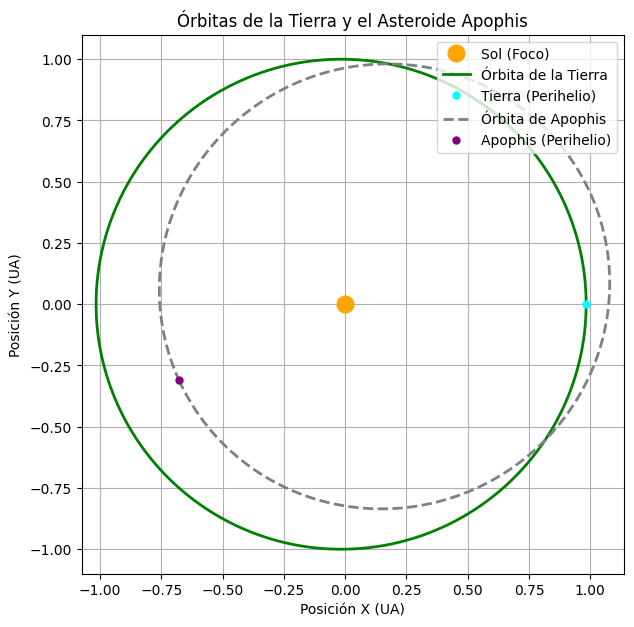

In [ ]:
# Parámetros orbitales
a_tierra = 1.000  # En AU
e_tierra = 0.0167
p_tierra = a_tierra * (1.0 - e_tierra**2)
a_apophis = 0.922  # En AU
e_apophis = 0.191
p_apophis = a_apophis * (1.0 - e_apophis**2)

# Para rotar la órbita
omega_apophis = np.radians(204.4)  # En radianes

# Ángulos para órbita completa
theta = np.linspace(0, 2 * np.pi, 1000)

# Trayectorias
r_tierra = p_tierra / (1.0 + e_tierra * np.cos(theta))
x_tierra = r_tierra * np.cos(theta)
y_tierra = r_tierra * np.sin(theta)
r_apophis = p_apophis / (1.0 + e_apophis * np.cos(theta))
x_apophis = r_apophis * np.cos(theta + omega_apophis)
y_apophis = r_apophis * np.sin(theta + omega_apophis)

# Graficación
plt.figure(figsize=(7, 7))
# El Sol sería el foco de ambas elipses
plt.plot(0, 0, 'o', color='orange', markersize=12, label='Sol (Foco)')
plt.plot(x_tierra, y_tierra, '-', color='green', linewidth=2, label='Órbita de la Tierra')
plt.plot(x_tierra[0], y_tierra[0], 'o', color='cyan', markersize=5, label='Tierra (Perihelio)')
plt.plot(x_apophis, y_apophis, '--', color='gray', linewidth=2, label='Órbita de Apophis')
plt.plot(r_apophis[0] * np.cos(omega_apophis), r_apophis[0] * np.sin(omega_apophis), 'o', color='purple', markersize=5, label='Apophis (Perihelio)')
plt.title('Órbitas de la Tierra y el Asteroide Apophis')
plt.xlabel('Posición X (UA)')
plt.ylabel('Posición Y (UA)')
plt.axis('equal')
plt.grid()
plt.legend(loc='upper right')

plt.show()

Velocidades Iniciales:

In [ ]:
print(f"Velocidad inicial de la Tierra: {v_tierra_0} m/s")
print(f"Velocidad inicial de Apophis: {v_apophis_0} m/s")

Velocidad inicial de la Tierra: [-2.97765061e+04 -5.39596266e+03  1.75383620e-01] m/s
Velocidad inicial de Apophis: [19641.60665406 32081.67286791 -1248.24123366] m/s


**Cuadraturas y Elementos Orbitales:**

Cálculo de algunos elementos orbitales y geométricos para la trayectoria de Apophis, en este caso sólo respecto al Sol, y graficación de la misma a partir de dichos elementos.

In [ ]:
# @title
G = 1  # Unidades canónicas

m1 = 3.003e-6  # En masas solares
r1_vec_0 = np.array([x_tierra[0], y_tierra[0], 0])
v1_vec_0 = v_tierra_0

m2 = 1.358e-20  # En masas solares
r2_vec_0 = np.array([r_apophis[0] * np.cos(omega_apophis), r_apophis[0] * np.sin(omega_apophis), 0])
v2_vec_0 = v_apophis_0

mu = G * (m1 + m2)
r_vec_0 = r1_vec_0 - r2_vec_0  # Vector posición relativo
r0 = np.linalg.norm(r_vec_0)  # Magnitud del vector posición

v_vec_0 = v1_vec_0 - v2_vec_0  # Vector velocidad relativa
v0 = np.linalg.norm(v_vec_0)  # Magnitud del vector velocidad

# Momento angular específico
h_vec = np.cross(r_vec_0, v_vec_0)  # Vector
h = np.sqrt(h_vec[0]**2 + h_vec[1]**2 + h_vec[2]**2)  # Magnitud

# Excentricidad
e_vec = np.cross(v_vec_0, h_vec)/mu - r_vec_0 / r0  # Vector
e1 = (e_vec@e_vec)**0.5  # Magnitud (magnitud de un vector)

epsilon = v0**2 / 2 - mu / r0
e2 = np.sqrt(1 + 2*epsilon*h**2 / mu**2) # Magnitud (fórmula)

# Semilatus rectum
p = h**2 / mu
# Distancia al periapsis
q = p / (1 + e1)
# Distancia al apoapsis
Q = p / (1 - e1)

print(f"Vector del momento angular específico: {h_vec}.")
print(f"Magnitud del momento angular específico: {h}.")
print(f"Vector de excentricidad: {e_vec}.")
print(f"Magnitud de la excentricidad: {e1}.")
print(f"Magnitud de la excentricidad (fórmula): {e2}.")
print(f"Semilatus rectum: {p}")
print(f"Distancia al periapsis: {q}")
print(f"Distancia al apoapsis: {Q}")

# ?????

Vector del momento angular específico: [   384.67931631  -2075.58890565 -47082.07009478].
Magnitud del momento angular específico: 47129.368464807.
Vector de excentricidad: [ 5.88450171e+14 -7.74634302e+14  3.89572287e+13].
Magnitud de la excentricidad: 973575662661000.8.
Magnitud de la excentricidad (fórmula): 973575662661001.0.
Semilatus rectum: 739652804492685.5
Distancia al periapsis: 0.7597281165297904
Distancia al apoapsis: -0.759728116529792


In [ ]:
G = pc.constantes.G

# Masas (en kg)
m_sun_kg = m_sol
m_apophis_kg = m_apophis

# Condiciones iniciales
r_rel_vec = r_apophis_0 - r_sol_0
r_0 = np.linalg.norm(r_rel_vec)
v_rel_0 = v_apophis_0 - v_sol_0
v_mag_0 = np.linalg.norm(v_rel_0)

mu_A_S = G * (m_sun_kg + m_apophis_kg)

# Momento angular específico
h_vec = np.cross(r_rel_vec, v_rel_0)  # Vector
h = np.linalg.norm(h_vec)  # Magnitud

# Vector de excentricidad
e_vec = (np.cross(v_rel_0, h_vec) / mu_A_S) - (r_rel_vec / r_0)  # Vector
e = np.linalg.norm(e_vec)  # Magnitud

# Semilatus rectum
p = h**2 / mu_A_S

# Distancia al periapsis
q = p / (1 + e)

# Distancia al apoapsis
# Casos para órbita parabólica, elíptica o hiperbólica
if e < 1:
    Q = p / (1 - e)
else:
    Q = np.inf

# Semieje mayor
epsilon = (v_mag_0**2 / 2.0) - (mu_A_S / r_0)
if epsilon < 0: # Órbita elíptica
    a = -mu_A_S / (2.0 * epsilon)
elif epsilon == 0: # Órbita parabólica
    a = np.inf
else: # Órbita hiperbólica
    a = mu_A_S / (2.0 * epsilon)


print(f"\nElementos orbitales de Apophis con respecto al Sol:")
print(f"Vector del momento angular específico (h_vec): {h_vec} m^2/s.")
print(f"Magnitud del momento angular específico (h): {h:.4e} m^2/s.")
print(f"Vector de excentricidad (e_vec): {e_vec}.")
print(f"Magnitud de la excentricidad (e): {e:.4f}.")
print(f"Semilatus rectum (p): {p:.4e} m.")
print(f"Distancia al periapsis (q): {q:.4e} m.")
print(f"Distancia al apoapsis (Q): {Q:.4e} m." if Q != np.inf else f"Distancia al apoapsis (Q): Infinito.")
print(f"Semieje mayor (a): {a:.4e} m." if a != np.inf else f"Semieje mayor (a): Infinito.")


Elementos orbitales de Apophis con respecto al Sol:
Vector del momento angular específico (h_vec): [-9.87568839e+13  2.23703559e+14  4.19553560e+15] m^2/s.
Magnitud del momento angular específico (h): 4.2027e+15 m^2/s.
Vector de excentricidad (e_vec): [ 0.17144596 -0.08724344  0.00868736].
Magnitud de la excentricidad (e): 0.1926.
Semilatus rectum (p): 1.3309e+11 m.
Distancia al periapsis (q): 1.1160e+11 m.
Distancia al apoapsis (Q): 1.6483e+11 m.
Semieje mayor (a): 1.3821e+11 m.


Graficación:

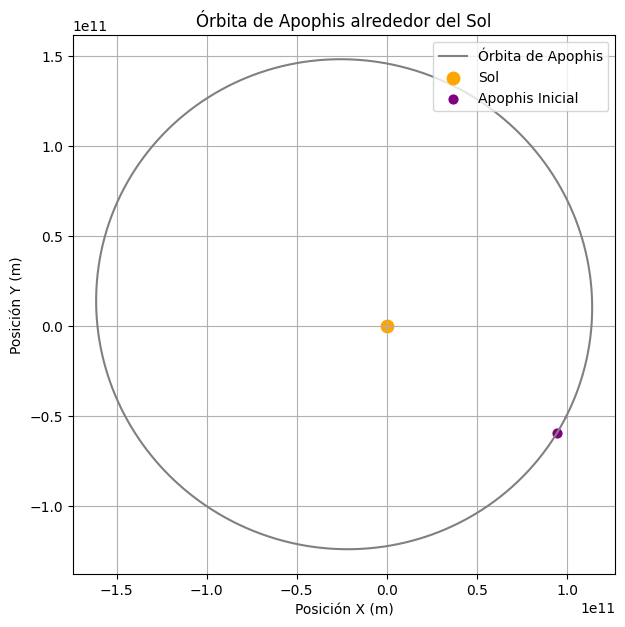

In [ ]:
# Graficación de la trayectoria de Apophis a partir de algunos elementos orbitales
# Definir las coordenadas del plano orbital
h_unit = h_vec / h
# e apunta al periapsis
e_unit = e_vec / e
# Vector perpendicular a h y e
p_unit = np.cross(h_unit, e_unit)

# Para graficar toda la órbita
num_points = 1000
theta_vals = np.linspace(0, 2 * np.pi, num_points)

# Coordenadas
r_vals = p / (1 + e * np.cos(theta_vals))
x_orbit = r_vals * np.cos(theta_vals)
y_orbit = r_vals * np.sin(theta_vals)

# Transformar las coordenadas al sistema de referencia original (Sol en el origen)
x_inertial = x_orbit * e_unit[0] + y_orbit * p_unit[0]
y_inertial = x_orbit * e_unit[1] + y_orbit * p_unit[1]
z_inertial = x_orbit * e_unit[2] + y_orbit * p_unit[2]

plt.figure(figsize=(7, 7))
plt.plot(x_inertial, y_inertial, label='Órbita de Apophis', color='gray')
plt.scatter(0, 0, color='orange', s=80, marker='o', label='Sol')
plt.scatter(r_rel_vec[0], r_rel_vec[1], color='purple', s=40, marker='o', label='Apophis Inicial')
plt.xlabel('Posición X (m)')
plt.ylabel('Posición Y (m)')
plt.title('Órbita de Apophis alrededor del Sol')
plt.axis('equal')
plt.grid()
plt.legend(loc='upper right')
plt.show()

Un Par de Extras:

In [ ]:
# Vis Viva
v_2 = mu_A_S * (2/r_0 - 1/a)
v = np.sqrt(v_2)

# Semieje mayor a partir de la Vis Viva
a = mu_A_S / (2*mu_A_S/r_0 - v_2)

print(f"Vis Viva: {v} m/s.")
print(f"Semieje mayor a partir de la Vis Viva: {a} m.")

Vis Viva: 37637.541791857024 m/s.
Semieje mayor a partir de la Vis Viva: 138212098872.04874 m.


**Determinación de $(p, e, I, \Omega, \omega, f)$ en el Punto de Máxima Aproximación:**

Recopilación de elementos orbitales de Apophis a partir de las definiciones matemáticas, calculados en el momento de máxima aproximación con la Tierra.

In [ ]:
# Llamado a los datos del asteoride
tabla, jd, X = pc.consulta_horizons(id='Apophis',location='@SSB', epochs='2029-04-13')

# Posiciones y velocidades
rvec = X[:3]
r = np.linalg.norm(rvec)
vvec = X[3:]
v = np.linalg.norm(vvec)

rad = 180 / np.pi
mu = pc.constantes.mu_sun  # Aproximación

# Momento angular relativo
hvec = np.cross(rvec, vvec)
h = np.linalg.norm(hvec)

# Vector de excentricidad
evec = np.cross(vvec, hvec) / mu - rvec / r
e = np.linalg.norm(evec)

# Vector de nodos
nvec = np.cross([0,0,1], hvec)
n = np.linalg.norm(nvec)

# Semilatus rectum
p = h**2 / mu

# Inclinación
I = np.arccos(hvec[2]/h) * rad

# Argumento del periapsis
omegap = np.arccos(nvec@evec/(n*e))
omega = omegap if evec[2] > 0 else 2*np.pi - omegap
arg_del_peri = omega*rad

# Longitud del nodo ascendente
Omegap = np.arccos(nvec@[1,0,0]/n)
Omegap = Omegap if evec[1] > 0 else 2*np.pi - Omegap
lon_nod_asc = Omegap*rad

# Anomalía verdadera
fp = np.arccos(rvec@evec/(r*e))
f = fp if rvec@vvec/r > 0 else 2*np.pi - fp
anom_ver = f*rad

print(f"Vector del momento angular relativo (hvec): {hvec}.")
print(f"Magnitud del momento angular relativo (h): {h}.")
print(f"Vector de excentricidad (evec): {evec}.")
print(f"Magnitud de la excentricidad (e): {e}.")
print(f"Vector de nodos (nvec): {nvec}.")
print(f"Magnitud de los nodos (n): {n}.")
print(f"Semilatus rectum (p): {p}.")
print(f"Inclinación (I): {I}.")
print(f"Argumento del periapsis (omega): {arg_del_peri}.")
print(f"Longitud del nodo ascendente (Omega): {lon_nod_asc}.")
print(f"Anomalía verdadera (f): {anom_ver}.")

Vector del momento angular relativo (hvec): [-1.01097721e+14  2.28926543e+14  4.18343471e+15].
Magnitud del momento angular relativo (h): 4190913272848689.5.
Vector de excentricidad (evec): [ 0.17044412 -0.09477399  0.00930522].
Magnitud de la excentricidad (e): 0.19524316596357127.
Vector de nodos (nvec): [-2.28926543e+14 -1.01097721e+14  0.00000000e+00].
Magnitud de los nodos (n): 250256091032929.03.
Semilatus rectum (p): 132344443784.44261.
Inclinación (I): 3.4233953136465947.
Argumento del periapsis (omega): 127.04786823564002.
Longitud del nodo ascendente (Omega): 203.82704062377596.
Anomalía verdadera (f): 232.18231919629272.


*Aquí están algunos elementos orbitales encontrados en JPL Small-Body Database. Claramente hay discrepancias con los valores anteriormente encontrados, pues hay diferencias en cuanto a las fechas para estos elementos, además de que los cálculos desarrollados anteriormente sólo toman en cuenta la presencia del Sol y el asteroide en todo el Sistema Solar.*

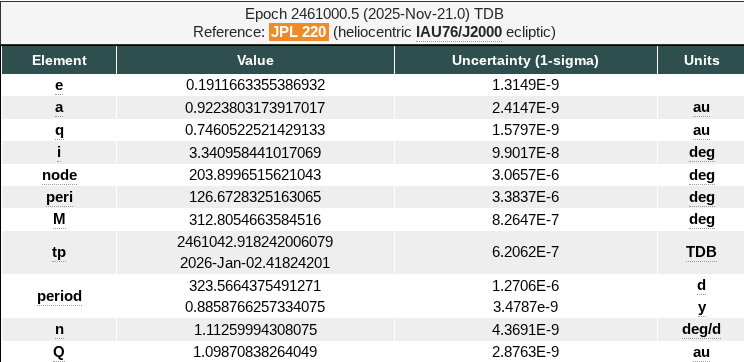

**Anomalías Excéntrica y Media:**

Cálculo de las anomalías excéntrica, media y verdadera, relacionadas entre sí.

In [ ]:
# Herramientas
deg = np.pi / 180
rad = 1/deg

# Elementos orbitales obtenidos de JPL Small-Body Database
e	= 0.1911663355386932
a	= 0.9223803173917017 * pc.constantes.au
q	= 0.7460522521429133 * pc.constantes.au
i	= 3.340958441017069*deg
node = 203.8996515621043*deg
peri = 126.6728325163065*deg
tp = 2461042.918242006079 * 86400
t0 = 2461000.5 * 86400
M0 = 312.8054663584516*deg
mu = pc.constantes.mu_sun + pc.constantes.mu_earth

t = Time("2029-04-13 18:52:00", scale='tdb').jd * 86400  # Momento exacto de la aproximación
h = np.sqrt(mu * a * (1 - e**2))
b = a * np.sqrt(1 - e**2)

def ecuacion_kepler(E):
  funcion = E - e*np.sin(E) - h/(a*b)*(t-tp)
  return funcion
E = newton(ecuacion_kepler, 0)
n = h/(a*b)
M = n*(t-tp)

E = M + e*np.sin(M)
pc.kepler_newton(M, e, delta=1e-15)
f = 2*np.arctan(np.sqrt((1+e)/(1-e))*np.tan(E/2))

print(f"Anomalía media: {M}.")
print(f"Anomalía excéntrica a primer orden: {E}.")
print(f"Anomalía verdadera: {f}.")

X = spy.conics([q, e, i, node, peri, M0, t0, mu], t)

Vec_estado = X
print(f"Vector de estado obtenido con SpiceyPy: {Vec_estado}")

Anomalía media: 23.25116151563998.
Anomalía excéntrica a primer orden: 23.06915313742472.
Anomalía verdadera: -2.2257998427391277.
Vector de estado obtenido con SpiceyPy: [-1.37521950e+11 -6.03332174e+10 -3.24029750e+07  1.56416671e+04
 -2.36292658e+04  1.63106298e+03]
